<a href="https://colab.research.google.com/github/Adriungs/SQL/blob/main/SQL_INTERMEDIO/3_Funciones_de_agregaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>
<font size = '4'><u><b>FRAGMENTACION DE DATAFRAME</b></u></font>
</center>

En este caso las explicaciónes de los codigos de python no son importantes,sin embargo, si voy a detallar que lo que hizo el codigo en python es crearme 3 tablas dividiendo el contenido del archivo.

 **¿Porque fragmentamos el dataframe?**

  Como necesitamos unir multiples tablas para futuras prácticas lo conveniente es dividirlo usando solo una base de datos.

Otras bases de datos podrian no estar correlacionadas y estaremos juntando datos diferentes ó que nada tienen que ver con lo que estamos analizando.

En las aplicaciones reales se usan multiples tablas de diferentes sectores eso es lo que hicimos al fragmentar.

Si lo pensamos en aplicaciones reales hay tres sectores que requieren diferentes tablas:


1.   Clientes
2.   Productos
3.   Ventas



In [ ]:
#Nueva base de datos
!pip install jupysql --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.8/270.8 kB 4.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import sqlite3

# 1. Cargar el archivo con tus columnas reales
df_original = pd.read_csv('retail_ferreteria.csv')

# 2. Normalización ajustada a tu dataset

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]

# 3. Guardar en el motor SQLite
conn = sqlite3.connect('ferreteria.db')

try:
  clientes.to_sql('clientes', conn, if_exists='replace', index=False)
  productos.to_sql('productos', conn, if_exists='replace', index=False)
  ventas.to_sql('ventas', conn, if_exists='replace', index=False)
finally:
    conn.close()  # <-- Esto libera el archivo y evita el error "database is locked"

print("¡Base de datos 'ferreteria.db' creada y liberada con éxito!")



¡Base de datos 'ferreteria.db' creada y liberada con éxito!


In [ ]:
%load_ext sql
%sql sqlite:///ferreteria.db
%config SqlMagic.feedback = False
%config SqlMagic.displaylimit = 0

Connecting to 'sqlite:///ferreteria.db'

<center>
<font size = '6' color =black><u><b>Funciones de agregación — COUNT, SUM, AVG, MIN, MAX<b/></u></font>
</center>

A veces no queremos ver cada fila individualmente, sino obtener un resumen de la información:

¿Cuántos herramientas hay en total?
¿Cuál es el promedio de productos vendidos?
¿Cuál es el precio_unitario más bajo y cual es el precio_unitario más alto?
👉 Para eso existen las funciones de agregación en SQL.

**Las principales son:**

* COUNT() → cuenta la cantidad de registros.
* SUM() → suma los valores de una columna.
* AVG() → calcula el promedio.
* MIN() → devuelve el valor mínimo.
* MAX() → devuelve el valor máximo.

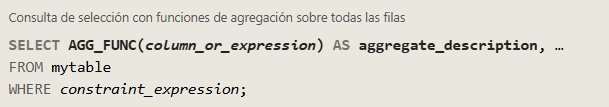


Asi es la estructura luego del SELECT se agregar la funcion junto con su columna EJEMPLO:

SELECT SUM(COLUMNA)

###También se pueden combinar varias funciones de agregación

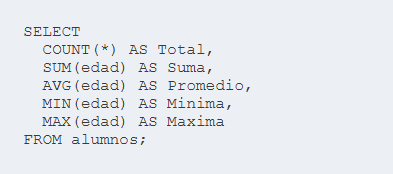


<center>
<font size = '6' color =black><u><b>DIFERENCIA ENTRE COUNT y GROUP BY<b/></u></font>
</center>


La diferencia principal es que COUNT() calcula el número total de registros, mientras que GROUP BY divide o clasifica esos datos en categorías (grupos) para que COUNT() (u otras funciones) se aplique a cada grupo por separado.

* COUNT(): Cuenta filas. Por sí sola, te dice cuántos registros hay en toda la tabla (o cuántos cumplen una condición).

* GROUP BY: Agrupa filas que comparten el mismo valor en una columna. No calcula nada por sí solo, sino que organiza los datos.

Para ver y entender mejor esta diferencia en la práctica, veamos cómo interactúan juntos en una consulta:

 ### Usar COUNT()
 Solo cuenta todos los registros de la tabla de una sola vez.


 SELECT COUNT(*) FROM empleados;

-- Devuelve: Un único número con el total de empleados en la empresa (ej. 100).

---


### Usar COUNT() junto con GROUP BY

Agrupa a los empleados por departamento y cuenta cuántos hay en cada uno.


SELECT departamento, COUNT(*)

FROM empleados

GROUP BY departamento;

-- Devuelve: Una lista de cada departamento con su respectiva cantidad de empleados.

---

<center>
<font size = '6' color =black><u><b>EJERCICIOS<b/></u></font>
</center>

En estos ejercicios vamos a usar todas las funciones de agregación.

1. Cual fue el maximo total de ventas osea cuanto se gano en dinero con el total de ventas?

clientes = df_original[['id_cliente', 'nombre_cliente', 'provincia']].drop_duplicates()

productos = df_original[['producto', 'categoria', 'precio_unitario']].drop_duplicates()

ventas = df_original[['id_venta', 'fecha_hora', 'id_cliente', 'producto', 'cantidad', 'total_venta', 'sucursal', 'medio_pago']]


En el siguiente codigo podemos ver la cantidad de dinero total con las ventas totales=

In [ ]:
%%sql
SELECT SUM(v.total_venta) AS total_venta_maximo
FROM ventas AS v;

total_venta_maximo
233735588.71000004


También podemos ver la cantidad total de productos vendidos o el maximo de productos vendidos

In [ ]:
%%sql
SELECT SUM(v.cantidad) AS cantidad_total
FROM ventas AS v;



cantidad_total
9146.0


2. Ahora vamos a contar cuantos productos nos quedan en stock

In [ ]:
%%sql
SELECT COUNT(p.producto) AS productos_stock
FROM productos AS p;

productos_stock
2958


Aca nos encontramos un problema y es que count no sabe como clasificar y cuenta todo junto por eso necesitamos GROUP BY pero eso lo vamos a ver en la siguiente clase

3. Calcular el promedio del precio unitario y de la cantidad

In [ ]:
%%sql
SELECT AVG(p.precio_unitario) AS promedio_precio_unitario, AVG(v.cantidad) AS promedio_cantidad
FROM productos AS p
LEFT JOIN ventas AS v
  ON p.producto = v.producto;

promedio_precio_unitario,promedio_cantidad
25279.07468463613,2.9572438416250018


Aca paso lo mismo como todavia no vemos GROUP BY calcula sobre el total, de todas formas estos ejercicios van a estar en la siguente clase pero incluyendo al groupby

4. Ahora vamos a ver la minima fecha y la maxima o última fecha. De esta forma vemos que facil se sacan estas dos informaciones

In [ ]:
%%sql
SELECT
  MIN(v.fecha_hora) AS fecha_minima,
  MAX(v.fecha_hora) AS fecha_maxima
FROM ventas AS v;

fecha_minima,fecha_maxima
2024-09-16 12:59:32,2025-09-16 10:56:40


5. Ahora vamos a ver para la sucursal de Palermo el promedio de la cantidad de ventas

In [ ]:
%%sql
SELECT AVG(v.cantidad) AS promedio_cantidad_ventas
FROM ventas AS v
WHERE v.sucursal LIKE '%Palermo%';

promedio_cantidad_ventas
2.9141742522756826
